Neste notebook serão realizadas previsões para os anos de 2023 e 2024. 

In [ ]:
import os
import torch 
import numpy as np
import pandas as pd
from epiweeks import Week
import preprocess_data as prep
import matplotlib.pyplot as plt
from models import LSTMLogNormalModel, train, sum_regions_predictions

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

device='cuda' if torch.cuda.is_available() else 'cpu'


Data to train the model using the Northeast data:

In [4]:
STATE = 'CE'
TEST_YEAR = 2023
boxcox = False
episcanner = False
columns_to_normalize=['casos','epiweek', 'biome', 'enso']

df = prep.load_cases_data()
df = df.loc[df.uf.isin(['BA', 'CE', 'PE', 'PB', 'PI', 'RN', 'MA', 'AL', 'SE'])]
df = df.loc[df.index >= pd.to_datetime(Week(2015,41).startdate())]
enso = prep.load_enso_data()

# generate the samples to train and test based on the regional data 
X_train, y_train = prep.generate_regional_train_samples(df,
                                                        enso, 
                                                        TEST_YEAR,
                                                        columns_to_normalize=columns_to_normalize,
                                                        boxcox = boxcox)

In [5]:
X_train.shape

torch.Size([585, 89, 5])

Training the model: 

In [6]:
model = LSTMLogNormalModel(hidden=64, features=5, 
                  predict_n=52, look_back=89)

#model_path = f'./saved_models/trained_dengue_CE_2022_teste.pt'
#model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
#model.to(device)

model

LSTMLogNormalModel(
  (lstm1): LSTM(5, 64, batch_first=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(64, 64, batch_first=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc_mu): Linear(in_features=64, out_features=52, bias=True)
  (fc_log_sigma): Linear(in_features=64, out_features=52, bias=True)
)

In [ ]:
label = f'{STATE}_{TEST_YEAR-1}_teste'
batch_size = 1
epochs = 100
cross_val = False
verbose = 1
doenca = 'dengue'
min_delta = 0
patience= 20

model = train(model, X_train, y_train, label=label, batch_size=batch_size, epochs=epochs,
                                        overwrite=True, cross_val = cross_val, monitor='val_loss',
                                        verbose=verbose, doenca=doenca,
                                        min_delta = min_delta, patience=patience)



Apply the model to forecast the 2023 season in CE (state):

In [7]:
STATE = 'CE'

df = prep.load_cases_data()
df = df.loc[df.uf == STATE]

In [8]:
%%time
df_preds_23 = sum_regions_predictions(model, df, enso, TEST_YEAR, columns_to_normalize, n_passes = 500)

df_preds_23.head()

CPU times: user 5.23 s, sys: 483 ms, total: 5.71 s
Wall time: 5.58 s


,pred,lower_50,upper_50,lower_80,upper_80,lower_90,upper_90,lower_95,upper_95,date
0,45.099041,24.039229,95.849955,12.398825,201.577491,8.980197,288.132778,6.989603,502.492636,2022-10-09
1,40.783891,21.974100,85.764148,11.964260,178.693760,7.972990,283.327332,6.556042,402.103471,2022-10-16
2,48.138393,23.760658,104.604080,12.428797,214.011539,9.156634,335.316443,6.629496,642.051960,2022-10-23
3,47.494921,22.587662,98.514925,11.983621,214.356157,8.757760,335.536802,5.939459,535.379458,2022-10-30
4,47.820239,24.550789,93.324247,12.452978,223.698416,9.117285,361.519408,7.954373,482.062026,2022-11-06


In [9]:
df_w = df.loc[df.uf == STATE][['casos']].resample('W-SUN').sum()

df_w = prep.add_epiweek_label(df_w)

df_w_casos = df_w.loc[df_w.year == TEST_YEAR]

df_w_casos.head()

,casos,epiweek_label,epiweek,year
date,,,,
2022-10-09,216,202301,1,2023
2022-10-16,186,202302,2,2023
2022-10-23,132,202303,3,2023
2022-10-30,133,202304,4,2023
2022-11-06,165,202305,5,2023


Plot the predictions:

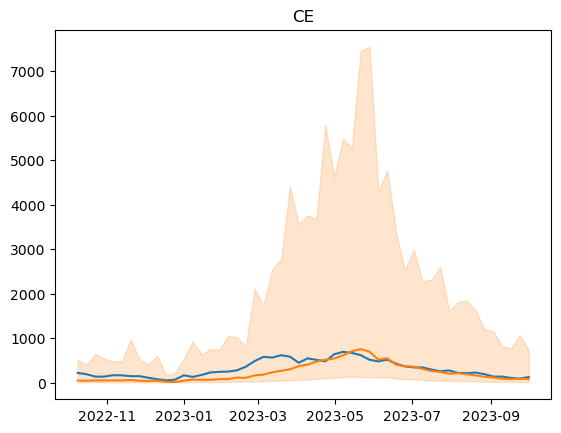

In [10]:
fig, ax = plt.subplots()

ax.plot(df_w_casos.casos, label = 'Data')

ax.plot(df_preds_23.date, df_preds_23.pred, label = 'preds')

ax.fill_between( df_preds_23.date, df_preds_23.lower_95, df_preds_23.upper_95, color = 'tab:orange', alpha = 0.2)

ax.set_title(f'{STATE}')

plt.show()